## 1. 変数データの歪み（Skewness）

年収データで、大部分が低い年収帯に集中しており、一部に高年収者が存在する場合、
一部の高年収者によって<strong>平均値が右側に引っ張られる</strong>。

-> <strong>平均値 vs 中央値：</strong> 平均値 ＞ 中央値 となる傾向がある。

-> データの大部分は左側に集中し、右側に長い裾が伸びた形になる（<strong>Right-Skewed</strong>）。

<img src="../images/image-71_1.png" width="800">

<br>

## 2. 一方に偏ったデータの問題点

- <strong>外れ値（Outlier）の影響</strong> <br> 
一方に偏ったデータでは、一部の非常に大きな値が平均・分散・回帰モデルなどに<strong>過度に大きな影響</strong>を与える。

- <strong>統計・機械学習モデルの性能が不安定になる</strong>  
データの歪みが大きいと、モデルが一般的なパターンを十分に学習できず、<strong>特定の外れ値に過学習する</strong>リスクが高くなる。

<br>

## 3. 解決策：分布変換（Box-Cox・Yeo-Johnson Transformation）

- 外れ値のデータを削除せず、そのまま保持する。
- 全体的な数値の大きさや分布の形を変換し、<strong>外れ値の相対的な影響や歪みを小さくする</strong>。
- 元の年収データと変換後のデータは<strong>同じ対象・同じ情報</strong>を表しているが、表示される数値のスケールは異なる。

#### 例）

$2,800（元の年収値） → -1.707895（変換後の値）

2つは異なるデータではなく、<strong>同じ人の年収を別のスケールで表した変換値</strong>である。

<br>

<strong>※ Box-Cox vs Yeo-Johnson</strong>

<p style="color:#ff0000;">
<strong>Box-Cox（1964年）</strong>：正の値のデータのみ処理可能
</p>

<p style="color:#ff0000;">
<strong>Yeo-Johnson（2000年）</strong>：0や負の値を含むデータも処理可能
</p>

<br>

<p style="color:#1683e8;">
※ 機械学習の学習時には、必要に応じて<strong>分布変換した変数</strong>を活用できる。
</p>

<p style="color:#1683e8;">
分布変換を適用したからといって、モデルの性能が必ず向上するわけではない。
（データの特徴やモデルのアルゴリズムによって異なる）
</p>

<br>

### # Box-Cox変換を用いて、年収データの歪みを調整し、変換前後の分布を比較する。

(今回の `salary` データはすべて正の値であるため、**Box-CoxとYeo-Johnsonの両方を適用できる**。
ただし、変換方法が異なるため、**変換後の値が完全に同じになるとは限らない**。)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

<br>

<br>

#### 1. 30人の会社員の年収データ

In [3]:
df = pd.DataFrame({
    'salary': [
        2800, 2900, 3000, 3100, 3200,
        3300, 3400, 3500, 3600, 3700,
        3800, 3900, 4000, 4100, 4200,
        4300, 4500, 4700, 4900, 5200,
        5500, 5800, 6200, 6800, 7500,
        8500, 10000, 12000, 15000, 20000
    ]
})

<br>

#### 2. 変換前のデータ確認

In [4]:
print("平均 :", df['salary'].mean())
print("中央値 :", df['salary'].median())

平均 : 5780.0
中央値 : 4250.0


<br>

#### 3. 変換前のヒストグラム

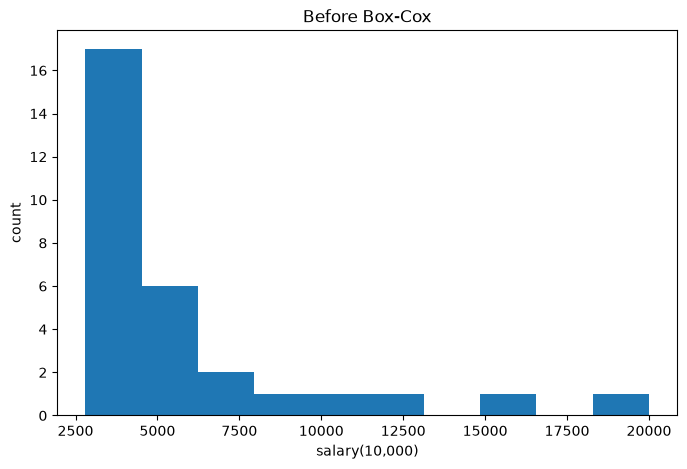

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(df['salary'], bins=10)

plt.xlabel('salary(10,000)')
plt.ylabel('count')
plt.title('Before Box-Cox')

plt.show()

<br>

#### 4. Box-Cox変換

In [6]:
pt = PowerTransformer(method='box-cox')
# pt = PowerTransformer(method='yeo-johnson')

salary_boxcox = pt.fit_transform(df[['salary']])

# 変換結果を新しい列として追加
df['salary_boxcox'] = salary_boxcox

<br>

#### 5. 変換後のデータ確認

In [7]:
display(df)

,salary,salary_boxcox
0,2800,-1.707895
1,2900,-1.543160
2,3000,-1.390453
3,3100,-1.248537
4,3200,-1.116338
5,3300,-0.992917
6,3400,-0.877450
7,3500,-0.769213
8,3600,-0.667566
9,3700,-0.571940


※ `PowerTransformer`はデフォルトで標準化も行うため、変換後の値は平均0を基準として負の値や正の値になる。

- **負の値** → 変換後の平均より相対的に小さい値
- **0付近** → 変換後の平均付近
- **正の値** → 変換後の平均より相対的に大きい値

<br>

#### 6. 変換後のヒストグラム

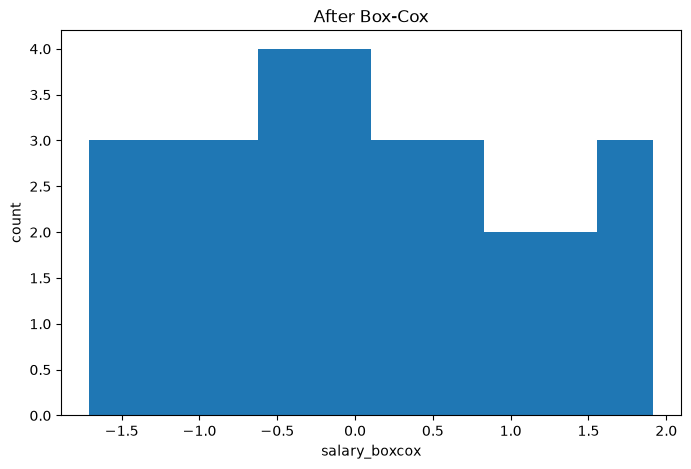

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df['salary_boxcox'], bins=10)

plt.xlabel('salary_boxcox')
plt.ylabel('count')
plt.title('After Box-Cox')

plt.show()

<br>

→ ヒストグラムを確認すると、分布が変化していることが分かる。

<img src="../images/image-71_2.png" width="600">